### 1. Classification: Importing Libraries
Before we begin, we import the necessary libraries for data handling, modeling, and evaluation.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, r2_score, roc_auc_score, mean_squared_error, mean_absolute_error, confusion_matrix, classification_report, roc_curve
from sklearn.datasets import load_iris, fetch_california_housing

### 2. Classification: Loading the Dummy Dataset
We create a small dataset predicting if a customer bought a product (1 = Yes, 0 = No) based on Age and Salary.


In [3]:
iris = load_iris()

X = iris.data
y = iris.target

print(X.shape)
print(y.shape)

(150, 4)
(150,)


### 3. Classification: Viewing the Data
Let's print the dataset to understand its structure.


In [4]:
print(X[:5])

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]


### 4. Classification: Train-Test Split
We separate our independent features (X) and our target (y), then split them into training and testing sets.


In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)

(120, 4)
(30, 4)


### 5. Classification: Feature Scaling
Since Age and Salary have very different numerical ranges, we apply Standardization so they are weighted equally.


In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 6. Classification: Training the Classifier
We initialize and train a Logistic Regression model exclusively on our training data.


In [7]:
classifier = LogisticRegression()
classifier.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


### 7. Classification: Making Predictions
We use the trained model to predict the classification outcomes for our testing set.


In [8]:
y_pred_class = classifier.predict(X_test_scaled)
print('Predictions:', y_pred_class)

Predictions: [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


### 8. Classification: Evaluating the Model
We check the basic accuracy score of our classifier.


In [14]:
acc = accuracy_score(y_test, y_pred_class)
print('Accuracy Score:', acc)

Accuracy Score: 1.0


In [12]:
cm = confusion_matrix(y_test, y_pred_class)
print("Confusion Matrix:", cm, sep="\n")

Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [15]:
print("Classification Report:", classification_report(y_test, y_pred_class), sep="\n")

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## KNN Classifier

In [16]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))

KNN Accuracy: 1.0


### 9. Regression: Creating Dummy Data
Now we shift to Regression. We want to predict a continuous number: Salary based on Years of Experience.


In [17]:
data = fetch_california_housing()

X_reg = data.data
y_reg = data.target

print(X_reg.shape)
print(y_reg.shape)

(20640, 8)
(20640,)


### 10. Regression: Viewing the Data
Let's print the regression dataset.


In [18]:
print(X_reg[:5])

[[ 8.32520000e+00  4.10000000e+01  6.98412698e+00  1.02380952e+00
   3.22000000e+02  2.55555556e+00  3.78800000e+01 -1.22230000e+02]
 [ 8.30140000e+00  2.10000000e+01  6.23813708e+00  9.71880492e-01
   2.40100000e+03  2.10984183e+00  3.78600000e+01 -1.22220000e+02]
 [ 7.25740000e+00  5.20000000e+01  8.28813559e+00  1.07344633e+00
   4.96000000e+02  2.80225989e+00  3.78500000e+01 -1.22240000e+02]
 [ 5.64310000e+00  5.20000000e+01  5.81735160e+00  1.07305936e+00
   5.58000000e+02  2.54794521e+00  3.78500000e+01 -1.22250000e+02]
 [ 3.84620000e+00  5.20000000e+01  6.28185328e+00  1.08108108e+00
   5.65000000e+02  2.18146718e+00  3.78500000e+01 -1.22250000e+02]]


### 11. Regression: Train-Test Split
We split the regression features and target.


In [19]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

### 12. Regression: Training Models
We will train both a Linear Regressor and a Decision Tree Regressor to compare how they learn.


In [20]:
lin_reg = LinearRegression()
lin_reg.fit(X_train_r, y_train_r)

tree_reg = DecisionTreeRegressor(random_state=42)
tree_reg.fit(X_train_r, y_train_r)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


### 13. Regression: Making Predictions
Predicting salary values using both trained models.


In [21]:
y_pred_lin = lin_reg.predict(X_test_r)
y_pred_tree = tree_reg.predict(X_test_r)

print('Linear Predictions:', y_pred_lin)
print('Tree Predictions:', y_pred_tree)

Linear Predictions: [0.71912284 1.76401657 2.70965883 ... 4.46877017 1.18751119 2.00940251]
Tree Predictions: [0.414   1.203   5.00001 ... 5.00001 0.66    2.172  ]


### 14. Regression: Evaluation Metrics
We evaluate the models using Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R2 Score.


In [22]:
print('--- Linear Regression ---')
print('MSE:', mean_squared_error(y_test_r, y_pred_lin))
print('MAE:', mean_absolute_error(y_test_r, y_pred_lin))
print('RMSE:', np.sqrt(mean_squared_error(y_test_r, y_pred_lin)))
print('R2:', r2_score(y_test_r, y_pred_lin))

print('\n--- Decision Tree ---')
print('MSE:', mean_squared_error(y_test_r, y_pred_tree))
print('MAE:', mean_absolute_error(y_test_r, y_pred_tree))
print('RMSE:', np.sqrt(mean_squared_error(y_test_r, y_pred_tree)))
print('R2:', r2_score(y_test_r, y_pred_tree))


--- Linear Regression ---
MSE: 0.555891598695242
MAE: 0.5332001304956983
RMSE: 0.7455813830127748
R2: 0.5757877060324526

--- Decision Tree ---
MSE: 0.495235205629094
MAE: 0.45467918846899225
RMSE: 0.7037294974840077
R2: 0.622075845135081


### 15. Advanced Classification Metrics: Setup
Here we use the exact manual target arrays provided in your lab manual to calculate advanced classification metrics.


In [78]:
y_true = [0, 1, 0, 1, 0, 1, 1, 0]
y_pred = [0, 1, 0, 0, 0, 1, 1, 1]
y_pred_proba = [0.1, 0.9, 0.2, 0.4, 0.3, 0.8, 0.7, 0.6]

### 16. Calculating Precision, Recall, and F1 Score
These metrics provide a much clearer picture of performance than accuracy alone, especially if data is imbalanced.


In [79]:
print('Accuracy:', accuracy_score(y_true, y_pred))
print('Precision:', precision_score(y_true, y_pred))
print('Recall:', recall_score(y_true, y_pred))
print('F1 Score:', f1_score(y_true, y_pred))

Accuracy: 0.75
Precision: 0.75
Recall: 0.75
F1 Score: 0.75


### 17. Confusion Matrix
We compute the confusion matrix to isolate True Positives, True Negatives, False Positives, and False Negatives.

|                     | Predicted 0 (Negative) | Predicted 1 (Positive) |
| ------------------- | ---------------------- | ---------------------- |
| Actual 0 (Negative) | 3 (True Negatives)     | 1 (False Positives)    |
| Actual 1 (Positive) | 1 (False Negatives)    | 3 (True Positives)     |


In [80]:
cm = confusion_matrix(y_true, y_pred)
print('Confusion Matrix:\n', cm)

Confusion Matrix:
 [[3 1]
 [1 3]]


### 18. Plotting the Confusion Matrix Heatmap
A visual representation of the confusion matrix using Seaborn.


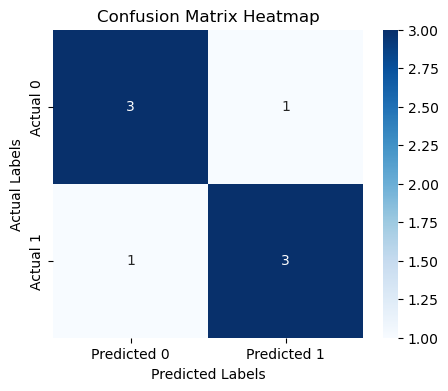

In [81]:
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, cmap='Blues', xticklabels=['Predicted 0','Predicted 1'], yticklabels=['Actual 0','Actual 1'])
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.title('Confusion Matrix Heatmap')
plt.show()

### 19. ROC Curve and AUC Computation
Finally, we evaluate the classifier using the Receiver Operating Characteristic (ROC) curve and Area Under the Curve (AUC).


In [82]:
roc_auc = roc_auc_score(y_true, y_pred_proba)
print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.9375


### 20. Plotting the ROC Curve:

- **Threshold:** A number between 0 and 1. If your model predicts a probability higher than this threshold, it labels it as 1 (Positive). If lower, it labels it as 0 (Negative). By default, this is set at 0.5, but the ROC curve tests all possible thresholds from 1 down to 0.

- **True Positive Rate (TPR / Y-Axis):** Out of all the actual positive cases in your data, how many did the model correctly find?

$$
TPR = \frac{\text{True Positives}}{\text{Actual Positives}}
$$

- **False Positive Rate (FPR / X-Axis):** Out of all the actual negative cases in your data, how many did your model falsely flag as positive?

$$
FPR = \frac{\text{False Positives}}{\text{Actual Negatives}}
$$

---

- **The Start $(0,0)$:** The threshold is set to $1.0$ (or higher). The model is so strict that it classifies absolutely nothing as positive. Because it found 0 positives, $TPR = 0$. Because it raised 0 false alarms, $FPR = 0$.

- **Moving Up to $(0, 0.75)$:** As you lower the threshold, the model starts labeling points as positive. It successfully catches 3 out of 4 actual positive cases ($TPR = 0.75$) without making any mistakes yet ($FPR = 0$).

- **Stepping Right to $(0.25, 0.75)$:** You lower the threshold a bit more. The model makes its first mistake—it accidentally classifies an actual negative sample as positive. The False Positive Rate jumps up.

- **Stepping Up to $(0.25, 1.0)$:** You lower the threshold further. The model successfully catches the final true positive sample. Now your $TPR = 1.0$ (you found them all!).

- **The End $(1.0, 1.0)$:** The threshold is set to $0.0$. The model is incredibly lazy and flags every single sample as positive. You found all positives ($TPR = 1.0$), but you also flagged every single negative as a false alarm ($FPR = 1.0$).

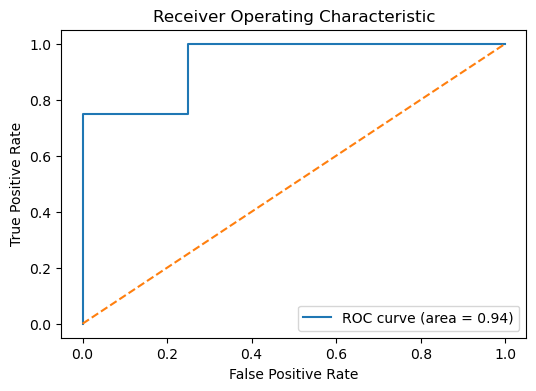

In [83]:
fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()

### 1. Optimal Threshold Choice

The point on the blue line **farthest from the diagonal baseline** maximizes the value of $\text{TPR} - \text{FPR}$. On your graph, this occurs at the top-left corner coordinate $(0, 0.75)$, making its corresponding threshold the mathematically optimal choice.

### 2. Baseline AUC Metrics

* **$\text{AUC} = 1.0$ (Perfect):** The line shoots straight up and across, forming a perfect square. The model separates classes flawlessly with zero overlap.
* **$\text{AUC} = 0.5$ (Random):** The line runs exactly along the diagonal baseline, meaning the model holds no predictive power and performs like a coin flip.

### 3. Your Model's Performance

An **$\text{AUC} = 0.94$** indicates an **excellent** ability to distinguish between the positive and negative classes, demonstrating a highly accurate and reliable model that performs far better than random guessing.